In [1]:
# 04_hmm_regime.ipynb
# Detect market regimes (Normal / Elevated / Crisis) using HMM

import pandas as pd
import numpy as np
import os
from hmmlearn import hmm
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

# Load saved data
data_path = os.path.expanduser("~/Desktop/SentriVaR-500/data")
df = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
macro_daily = pd.read_csv(f"{data_path}/macro_daily.csv", index_col="DATE", parse_dates=True)

returns = df.pct_change().dropna()

print(f"Price data: {df.shape}")
print(f"Macro data: {macro_daily.shape}")

Price data: (2141, 5)
Macro data: (2126, 2)


In [2]:
# HMM training as a reusable function
def train_hmm(returns, vix, ticker="AAPL", n_components=3, smooth_window=20):
    """
    Detect market regime using a Gaussian HMM.
    - returns: daily returns DataFrame
    - vix: VIX data Series
    - ticker: reference asset
    - n_components: number of regimes
    - smooth_window: smoothing window size
    """
    # Input features: returns + 20-day volatility + VIX
    hmm_data = returns[[ticker]].copy()
    hmm_data["volatility"] = returns[ticker].rolling(20).std()
    hmm_data = hmm_data.join(vix["VIX"]).dropna()
    dates = hmm_data.index
    X = hmm_data.values

    # Train HMM
    model = hmm.GaussianHMM(n_components=n_components, 
                             covariance_type="full", 
                             n_iter=100,
                             random_state=42)  # fixed seed for reproducibility
    model.fit(X)
    states = model.predict(X)

    # Smoothing
    smoothed = uniform_filter1d(states.astype(float), size=smooth_window)
    smoothed = np.round(smoothed).astype(int)
    state_series = pd.Series(smoothed, index=dates)

    # Auto-label states by mean VIX
    vix_aligned = vix["VIX"].reindex(dates)
    state_vix_means = {s: vix_aligned[state_series == s].mean() for s in range(n_components)}
    sorted_states = sorted(state_vix_means, key=state_vix_means.get)
    label_map = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}
    state_series = state_series.map(label_map)

    return state_series, dates, model

# Run training
state_series, dates, hmm_model = train_hmm(returns, macro_daily)

# Check regime proportions
labels = {0: "Normal", 1: "Elevated", 2: "Crisis"}
print("Regime proportions:")
for state, label in labels.items():
    ratio = (state_series == state).mean() * 100
    print(f"  {label}: {ratio:.1f}%")

Regime proportions:
  Normal: 52.7%
  Elevated: 16.6%
  Crisis: 30.7%


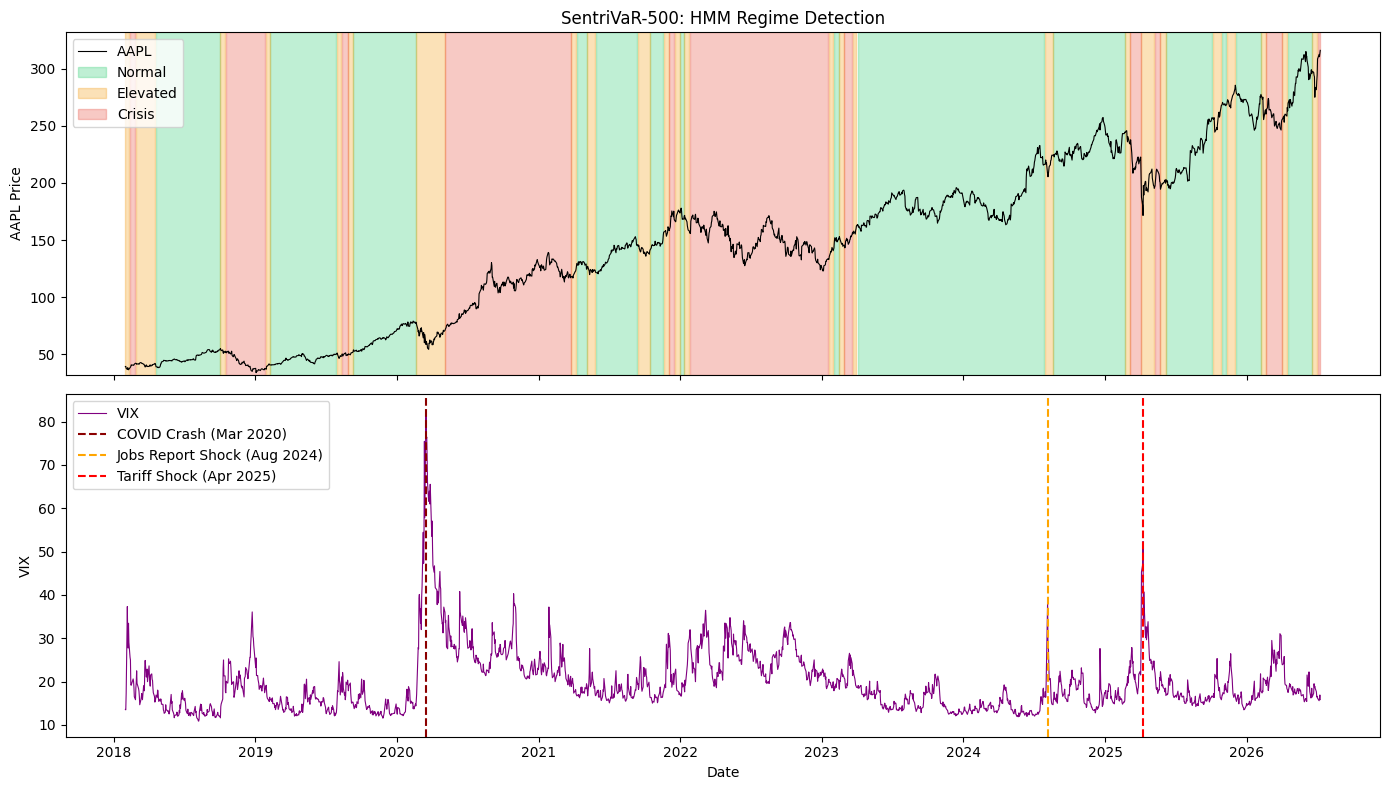

Saved: regime_detection_final.png


In [3]:
# Visualization as a reusable function
def plot_regimes(df, macro_daily, state_series, dates):
    colors = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}
    labels = {0: "Normal", 1: "Elevated", 2: "Crisis"}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Price + regime background
    aapl_price = df["AAPL"].reindex(dates)
    ax1.plot(dates, aapl_price, color="black", linewidth=0.8, label="AAPL", zorder=3)

    y_min = aapl_price.min() * 0.95
    y_max = aapl_price.max() * 1.05

    for state, color in colors.items():
        mask = state_series == state
        ax1.fill_between(dates, y_min, y_max,
                         where=mask.values, alpha=0.3,
                         color=color, label=labels[state])

    ax1.set_ylim(y_min, y_max)
    ax1.set_ylabel("AAPL Price")
    ax1.set_title("SentriVaR-500: HMM Regime Detection")
    ax1.legend(loc="upper left")

    # VIX + case study events
    ax2.plot(dates, macro_daily["VIX"].reindex(dates),
             color="purple", linewidth=0.8, label="VIX")
    ax2.axvline(pd.Timestamp("2020-03-16"), color="darkred",
                linestyle="--", linewidth=1.5, label="COVID Crash (Mar 2020)")
    ax2.axvline(pd.Timestamp("2024-08-05"), color="orange",
                linestyle="--", linewidth=1.5, label="Jobs Report Shock (Aug 2024)")
    ax2.axvline(pd.Timestamp("2025-04-07"), color="red",
                linestyle="--", linewidth=1.5, label="Tariff Shock (Apr 2025)")

    ax2.set_ylabel("VIX")
    ax2.set_xlabel("Date")
    ax2.legend(loc="upper left")

    plt.tight_layout()
    plt.savefig(os.path.expanduser("~/Desktop/SentriVaR-500/data/regime_detection_final.png"), dpi=150)
    plt.show()
    print("Saved: regime_detection_final.png")

plot_regimes(df, macro_daily, state_series, dates)

In [4]:
# Save regime data
regime_df = pd.DataFrame({
    "date": dates,
    "regime": state_series.values,
    "regime_label": state_series.map(labels).values
})
regime_df.to_csv(f"{data_path}/regime_states.csv", index=False)

print("Saved: regime_states.csv")
print("\nDays per regime:")
print(regime_df["regime_label"].value_counts())

Saved: regime_states.csv

Days per regime:
regime_label
Normal      1109
Crisis       647
Elevated     349
Name: count, dtype: int64


In [5]:
# Save regime data
regime_df = pd.DataFrame({
    "date": dates,
    "regime": state_series.values,
    "regime_label": state_series.map(labels).values
})
regime_df.to_csv(f"{data_path}/regime_states.csv", index=False)

print("Saved: regime_states.csv")
print("\nDays per regime:")
print(regime_df["regime_label"].value_counts())

Saved: regime_states.csv

Days per regime:
regime_label
Normal      1109
Crisis       647
Elevated     349
Name: count, dtype: int64


In [6]:
# Check average signals per regime (understand why Crisis looks overrepresented)
vix_aligned = macro_daily["VIX"].reindex(dates)
ret_aligned = returns["AAPL"].reindex(dates)
vol_aligned = returns["AAPL"].rolling(20).std().reindex(dates)

for state, label in labels.items():
    mask = state_series == state
    print(f"\n{label} ({mask.sum()} days)")
    print(f"  Avg VIX:        {vix_aligned[mask].mean():.1f}")
    print(f"  Avg return:     {ret_aligned[mask].mean():.4f}")
    print(f"  Avg volatility: {vol_aligned[mask].mean():.4f}")


Normal (1109 days)
  Avg VIX:        15.5
  Avg return:     0.0018
  Avg volatility: 0.0131

Elevated (349 days)
  Avg VIX:        24.5
  Avg return:     0.0004
  Avg volatility: 0.0226

Crisis (647 days)
  Avg VIX:        24.7
  Avg return:     0.0005
  Avg volatility: 0.0220


In [7]:
from sklearn.preprocessing import StandardScaler

# Retrain HMM with feature scaling applied
def train_hmm_scaled(returns, macro_daily, ticker="AAPL", n_components=3, smooth_window=20):
    # Build input features
    hmm_data = returns[[ticker]].copy()
    hmm_data["volatility"] = returns[ticker].rolling(20).std()
    hmm_data = hmm_data.join(macro_daily["VIX"]).dropna()
    dates = hmm_data.index

    # Scale (normalize each feature to mean 0, std 1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(hmm_data.values)

    # Train HMM
    model = hmm.GaussianHMM(n_components=n_components,
                             covariance_type="full",
                             n_iter=200,
                             random_state=42)
    model.fit(X_scaled)
    states = model.predict(X_scaled)

    # Smoothing
    smoothed = uniform_filter1d(states.astype(float), size=smooth_window)
    smoothed = np.round(smoothed).astype(int)
    state_series = pd.Series(smoothed, index=dates)

    # Auto-label states by mean VIX
    vix_aligned = macro_daily["VIX"].reindex(dates)
    state_vix_means = {s: vix_aligned[state_series == s].mean() for s in range(n_components)}
    sorted_states = sorted(state_vix_means, key=state_vix_means.get)
    label_map = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}
    state_series = state_series.map(label_map)

    return state_series, dates, model, scaler

# Retrain
state_series, dates, hmm_model, scaler = train_hmm_scaled(returns, macro_daily)

# Check regime proportions
print("Regime proportions (after scaling):")
for state, label in labels.items():
    ratio = (state_series == state).mean() * 100
    print(f"  {label}: {ratio:.1f}%")

Regime proportions (after scaling):
  Normal: 51.9%
  Elevated: 21.5%
  Crisis: 26.6%


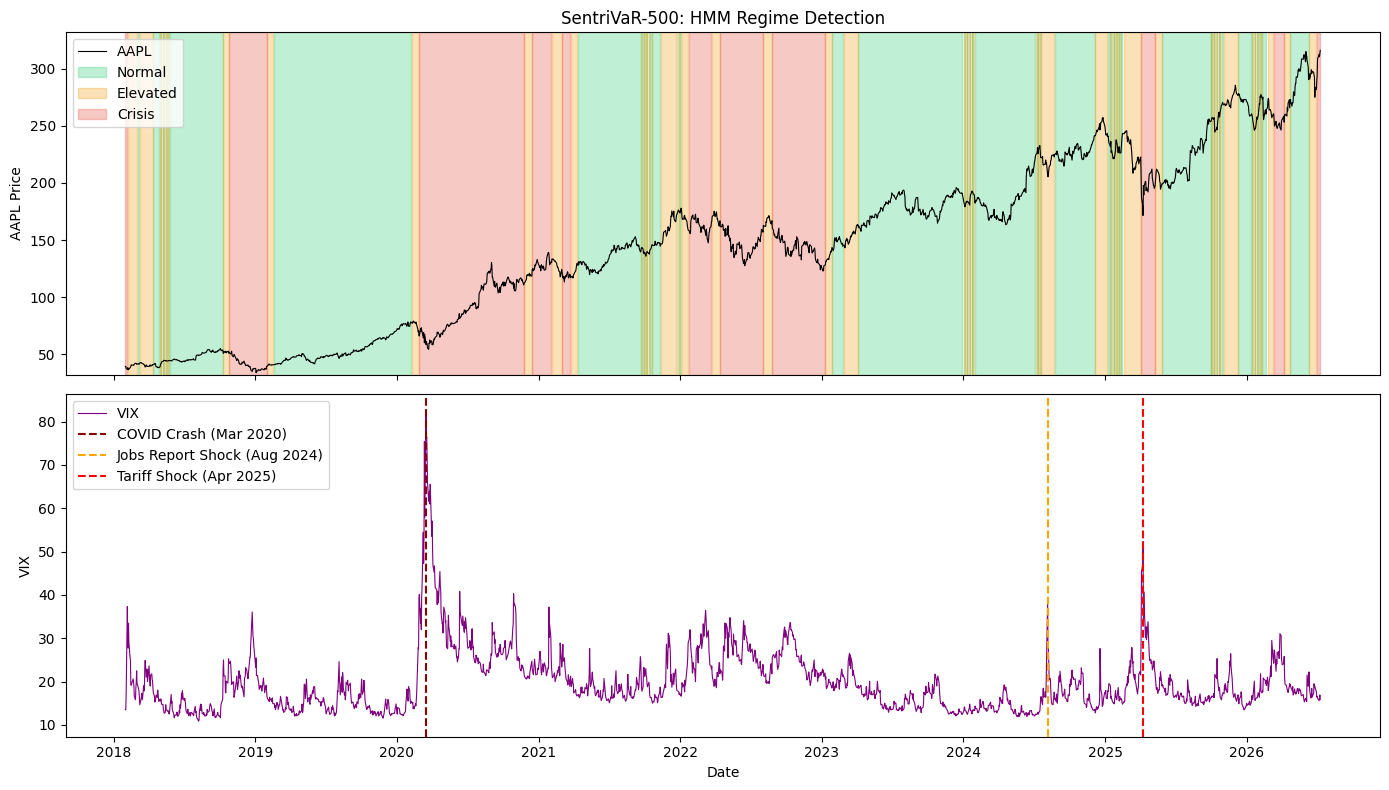

Saved: regime_detection_final.png


In [8]:
# Check v2 with visualization
plot_regimes(df, macro_daily, state_series, dates)

In [9]:
# Set initial regime priors based on VIX
def train_hmm_v3(returns, macro_daily, ticker="AAPL", smooth_window=30):
    hmm_data = returns[[ticker]].copy()
    hmm_data["volatility"] = returns[ticker].rolling(20).std()
    hmm_data = hmm_data.join(macro_daily[["VIX", "Spread"]]).dropna()
    dates = hmm_data.index

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(hmm_data.values)
    vix = macro_daily["VIX"].reindex(dates)

    model = hmm.GaussianHMM(n_components=3,
                             covariance_type="full",
                             n_iter=300,
                             random_state=42,
                             init_params="mc")  # exclude s, t → set them manually

    # Set initial values manually
    model.startprob_ = np.array([0.6, 0.3, 0.1])
    model.transmat_ = np.array([
        [0.95, 0.04, 0.01],
        [0.05, 0.90, 0.05],
        [0.02, 0.08, 0.90],
    ])

    model.fit(X_scaled)
    states = model.predict(X_scaled)

    smoothed = uniform_filter1d(states.astype(float), size=smooth_window)
    smoothed = np.round(smoothed).astype(int)
    state_series = pd.Series(smoothed, index=dates)

    state_vix_means = {s: vix[state_series == s].mean() for s in range(3)}
    sorted_states = sorted(state_vix_means, key=state_vix_means.get)
    label_map = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}
    state_series = state_series.map(label_map)

    return state_series, dates, model, scaler

state_series, dates, hmm_model, scaler = train_hmm_v3(returns, macro_daily)

print("Regime proportions (v3):")
for state, label in labels.items():
    ratio = (state_series == state).mean() * 100
    print(f"  {label}: {ratio:.1f}%")

Regime proportions (v3):
  Normal: 48.2%
  Elevated: 33.0%
  Crisis: 18.9%


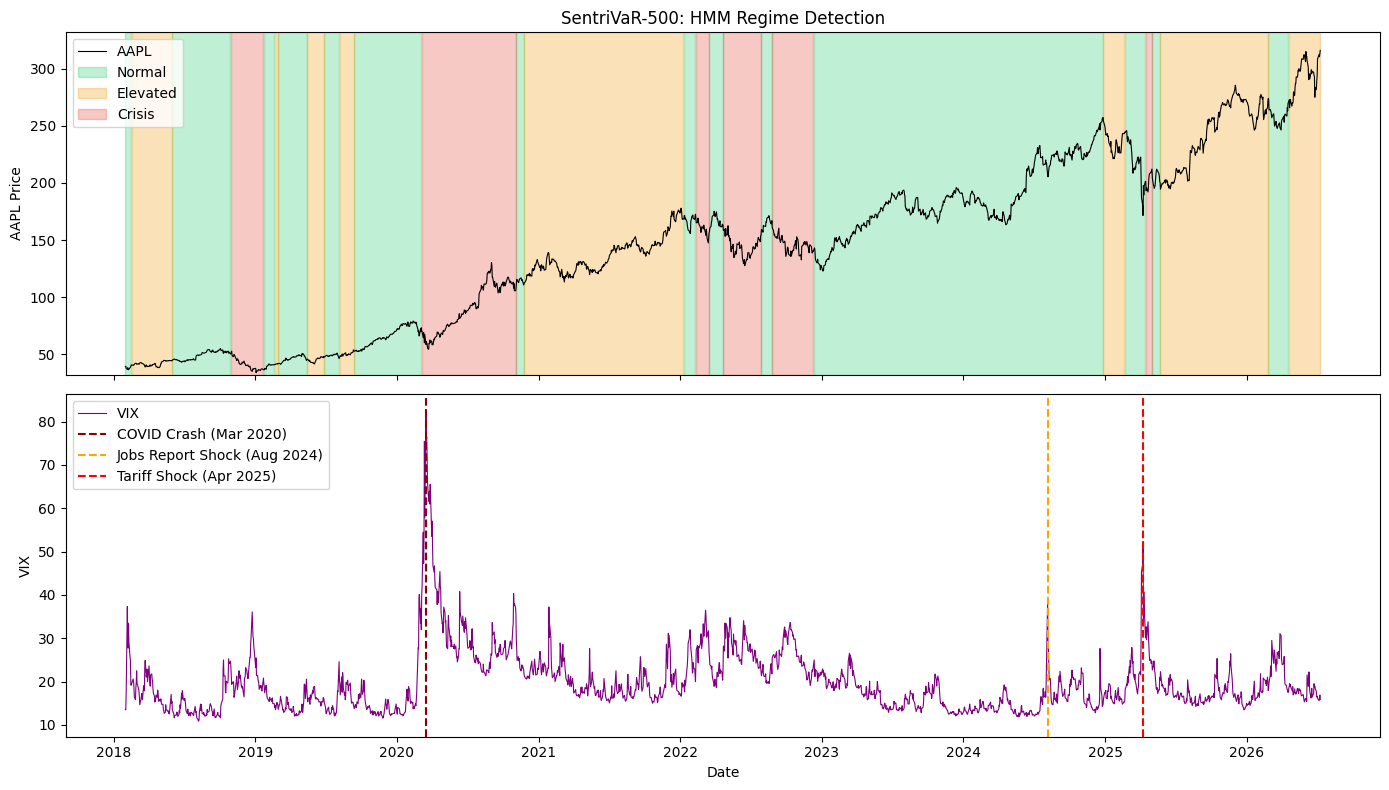

Saved: regime_detection_final.png


In [10]:
plot_regimes(df, macro_daily, state_series, dates)

In [11]:
# Save final regime data
regime_df = pd.DataFrame({
    "date": dates,
    "regime": state_series.values,
    "regime_label": state_series.map(labels).values
})
regime_df.to_csv(f"{data_path}/regime_states.csv", index=False)
print("Saved: regime_states.csv (v3 final)")

Saved: regime_states.csv (v3 final)
